# 1. INSTALLATION & IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import os
import re
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.decomposition import PCA
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz
from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import pickle
import os
from lightgbm import LGBMClassifier


In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
try:
    from sentence_transformers import SentenceTransformer, losses, models
    from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
    from torch.utils.data import DataLoader
    import torch
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("Sentence Transformers not available")

In [3]:
# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. DATA LOADING & EXPLORATION

In [4]:
#Load and validate the Career Path dataset
DATA_PATH = r"C:\Masar\masar____final\Career_Path_Dataset_for_Advanced_Tech_Jobs.csv"


try:
    # Load dataset with Latin-1 encoding for special characters
    df = pd.read_csv(DATA_PATH, encoding="latin1")

    
    # Data validation
    print(f" Dataset loaded successfully!")
    print(f"   - Rows: {df.shape[0]:,}")
    print(f"   - Columns: {df.shape[1]}")
    print(f"   - Columns: {', '.join(df.columns.tolist())}")
    
    
except FileNotFoundError:
    print(f" Error: File '{DATASET_PATH}' not found!")
    print(" Please check:")
    print("   - File exists in current directory")
    print("   - Correct file name spelling")
    print("   - File path is correct")
    
except Exception as e:
    print(f" Error loading dataset: {e}")


 Dataset loaded successfully!
   - Rows: 1,161
   - Columns: 8
   - Columns: Field, Subfields, Job roles, Programming Languages , Tools, Skills, Educational Background, Certifications


In [5]:
df.head()
df.tail()
df.sample(5)

,Field,Subfields,Job roles,Programming Languages,Tools,Skills,Educational Background,Certifications
528,Internet of Things (IoT),IoT Development & Sensors,Device Connectivity Engineer,"C, Python, Java, SQL, Shell","Wireshark, MQTT Broker, CoAP Client, Modbus Simulator, Serial Port Monitor, Docker, Ansible, Postman, Git, VPN Client","TCP/IP Networking, MQTT, CoAP, HTTP, TLS/SSL, VPN Configuration, Troubleshooting, Scalability, Performance Optimization, Communication","Bachelor's (Electrical Engineering, Computer Science, IoT)",Cisco IoT Fundamentals; AZ-220 Azure IoT Developer
486,Blockchain & Web3,Decentralized Finance (DeFi),Yield Farming Strategist,"Python, JavaScript, SQL, R, Solidity","Dune Analytics, DeFiLlama, Zapper, Debank, Web3.py, Ethers.js, Excel","Yield optimization, risk assessment, portfolio management, on-chain analytics, strategy backtesting, impermanent loss mitigation, leverage strategies, protocol research, data visualization, stakeholder communication","Bachelor's (Computer Science, Finance, Blockchain)",Certified Blockchain Developer; Ethereum Developer Certification
389,DevOps & SRE,GitOps,GitOps Engineer,"Go, Python, YAML, Bash, JavaScript","Argo CD, Flux, Git, Kubernetes, Helm, Terraform, Kustomize, GitHub Actions, Jenkins, Docker","Declarative infrastructure, Git workflows, CI/CD pipelines, Kubernetes manifests, Change automation, Version control, Reconciliation loops, Rollbacks, Monitoring, Collaboration","Bachelor s (Computer Science, Software Engineering)",AWS DevOps Engineer Professional; CKA Kubernetes Administrator
525,Internet of Things (IoT),IoT Development & Sensors,IoT Application Developer,"Python, JavaScript, Java, C#, Go","Node-RED, AWS IoT Core, Azure IoT Hub, MQTT Broker, Docker, VS Code, Postman, Git, Grafana, React Native","API Design, Cloud Integration, Data Visualization, REST/HTTP, WebSockets, Security Best Practices, Agile Methodologies, CI/CD, Testing, Problem Solving","Bachelor's (Computer Science, IoT)",Cisco IoT Fundamentals; AZ-220 Azure IoT Developer
1158,Emerging & Cross-Cutting,Spatial Computing beyond AR/VR,Spatial UX Engineer,"JavaScript, TypeScript, C#, Swift, HTML,CSS","Unity, WebXR, Figma, Sketch, ARKit, Blender, React, Git","spatial UX, 3D design principles, user research, prototyping, usability testing, accessibility, UI development, spatial navigation, attention to detail, collaboration","Bachelor's (Human-Computer Interaction, UX Design, Computer Science)",Apple Spatial Computing (visionOS) Certification; NVIDIA Omniverse Digital Twin Certification


In [6]:
df.shape

(1161, 8)

In [7]:
df.dtypes

Field                     object
Subfields                 object
Job roles                 object
Programming Languages     object
Tools                     object
Skills                    object
Educational Background    object
Certifications            object
dtype: object

In [8]:
#trims all whitespace in column names
df.columns = df.columns.str.strip()

In [9]:
# Missing values
print("\n📊 Missing Values:")
missing_data = df.isnull().sum()
for col, missing_count in missing_data.items():
    if missing_count > 0:
        missing_pct = (missing_count / len(df)) * 100
        print(f"   - {col}: {missing_count} ({missing_pct:.2f}%)")

# Target distribution
if 'Field' in df.columns:
    print(f"\n🎯 Target Distribution (Field):")
    field_counts = df['Field'].value_counts()
    for field, count in field_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   - {field}: {count} ({percentage:.2f}%)")
    print("\n----------------------------------------------------------")
    print(f"   - Total unique fields: {len(field_counts)}")
    print(f"   - Most common: '{field_counts.index[0]}' ({field_counts.iloc[0]} samples)")
    print(f"   - Least common: '{field_counts.index[-1]}' ({field_counts.iloc[-1]} samples)")
    # avoid division by zero for imbalance ratio
    if field_counts.iloc[-1] > 0:
        imbalance = field_counts.iloc[0] / field_counts.iloc[-1]
        print(f"   - Imbalance ratio: {imbalance:.1f}:1")
    else:
        print("   - Imbalance ratio: Infinity (least common class has 0 samples)")



📊 Missing Values:
   - Subfields: 1 (0.09%)
   - Programming Languages: 11 (0.95%)

🎯 Target Distribution (Field):
   - Artificial Intelligence: 105 (9.04%)
   - Data Science: 72 (6.20%)
   - Web Development: 70 (6.03%)
   - Cybersecurity: 70 (6.03%)
   - Mobile Development: 60 (5.17%)
   - Cloud Computing: 50 (4.31%)
   - Blockchain & Web3: 49 (4.22%)
   - DevOps & SRE: 47 (4.05%)
   - AR/VR & Spatial Computing: 40 (3.45%)
   - Game Development: 40 (3.45%)
   - UI/UX & Product Design: 40 (3.45%)
   - Robotics: 40 (3.45%)
   - Emerging & Cross-Cutting: 40 (3.45%)
   - Embedded Systems: 32 (2.76%)
   - Internet of Things (IoT): 32 (2.76%)
   - Digital & Marketing Technology: 32 (2.76%)
   - IT Support & System Administration: 32 (2.76%)
   - FinTech & InsurTech: 32 (2.76%)
   - Networking & Telecom: 32 (2.76%)
   - Database & Storage: 32 (2.76%)
   - ClimateTech & SpaceTech: 32 (2.76%)
   - Bioinformatics & HealthTech: 32 (2.76%)
   - Quantum Computing: 30 (2.58%)
   - CRM / ERP System

In [10]:
# Filling missing values with "None" to handle text-based columns.
# This ensures that all rows remain usable and prevents errors during later preprocessing steps
# such as splitting multi-value fields or applying encoding. Since the missing percentage is <1%,
# replacing with a neutral placeholder is the most appropriate approach.
df = df.fillna("None")

In [11]:
df.isnull().sum()

Field                     0
Subfields                 0
Job roles                 0
Programming Languages     0
Tools                     0
Skills                    0
Educational Background    0
Certifications            0
dtype: int64

In [12]:
#Check unique categories in the target column (Field)
df['Field'].value_counts()

Field
Artificial Intelligence                  105
Data Science                              72
Web Development                           70
Cybersecurity                             70
Mobile Development                        60
Cloud Computing                           50
Blockchain & Web3                         49
DevOps & SRE                              47
AR/VR & Spatial Computing                 40
Game Development                          40
UI/UX & Product Design                    40
Robotics                                  40
Emerging & Cross-Cutting                  40
Embedded Systems                          32
Internet of Things (IoT)                  32
Digital & Marketing Technology            32
IT Support & System Administration        32
FinTech & InsurTech                       32
Networking & Telecom                      32
Database & Storage                        32
ClimateTech & SpaceTech                   32
Bioinformatics & HealthTech               32
Quan

In [13]:
#Check samples from multi-value fields
df['Programming Languages'].head(10)
df['Skills'].head(10)
df['Tools'].head(10)
df['Certifications'].head(10)

0    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
1    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
2    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
3    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
4    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
5    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
6    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
7    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
8    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
9    AWS Machine Learning Specialty; Google ML Engineer; TensorFlow Developer
Name: Certifications, dtype: object

In [14]:
df['Certifications'].nunique()

97

 ANALYZING CLASS IMBALANCE...
 Field Distribution:
   - Total career fields: 28
   - Most common: 'Artificial Intelligence' (105 samples)
   - Least common: 'EdTech' (24 samples)
   - Imbalance ratio: 4.4:1
 RELATIVELY BALANCED - Good for model training


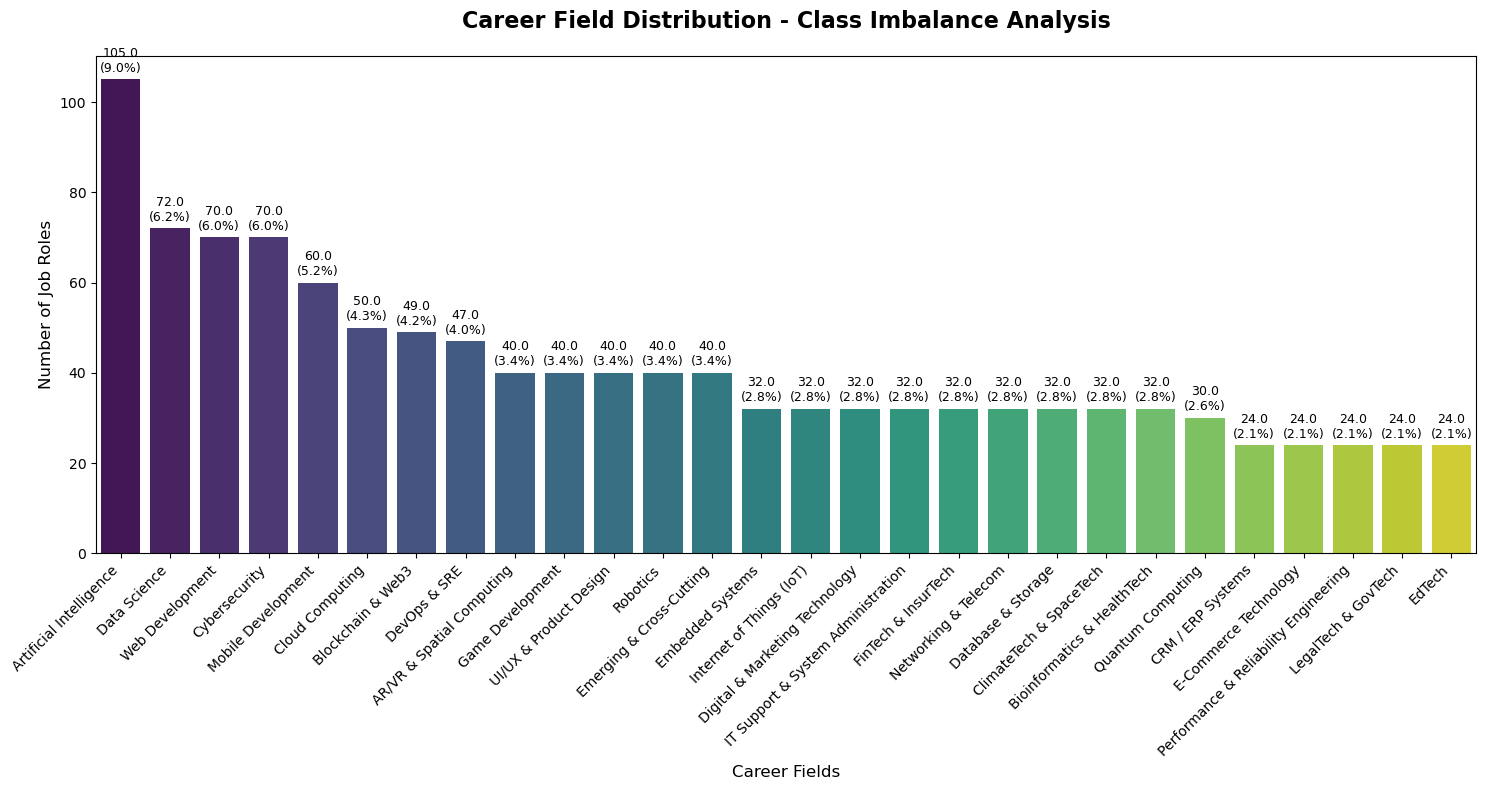

In [15]:
# Comprehensive Class Imbalance Analysis
# Critical for understanding if our model might be biased toward majority classes

print(" ANALYZING CLASS IMBALANCE...")

# Quantitative analysis
field_counts = df['Field'].value_counts()
print(f" Field Distribution:")
print(f"   - Total career fields: {len(field_counts)}")
print(f"   - Most common: '{field_counts.index[0]}' ({field_counts.iloc[0]} samples)")
print(f"   - Least common: '{field_counts.index[-1]}' ({field_counts.iloc[-1]} samples)")
print(f"   - Imbalance ratio: {field_counts.iloc[0] / field_counts.iloc[-1]:.1f}:1")

# Imbalance assessment
imbalance_ratio = field_counts.iloc[0] / field_counts.iloc[-1]
if imbalance_ratio > 10:
    print(" SEVERE IMBALANCE - Consider oversampling/class weights")
elif imbalance_ratio > 5:
    print(" MODERATE IMBALANCE - May need balancing techniques")
else:
    print(" RELATIVELY BALANCED - Good for model training")

# Enhanced visualization
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=df, x="Field", order=field_counts.index, 
                   palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Career Field Distribution - Class Imbalance Analysis", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Career Fields", fontsize=12)
plt.ylabel("Number of Job Roles", fontsize=12)

# Add percentage labels
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(height/total)*100:.1f}%'
    ax.text(p.get_x() + p.get_width()/2., height + 1,
            f'{height}\n({percentage})', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [16]:
# Comprehensive Class Distribution Analysis & Strategy Decision

print("QUANTITATIVE CLASS DISTRIBUTION ANALYSIS")
print("=" * 55)

# Calculate field percentages
field_percentages = df['Field'].value_counts(normalize=True) * 100

# Display the distribution
print(" FIELD DISTRIBUTION (%):")
print(field_percentages)

print("\n" + "=" * 55)
print("IMBALANCE ASSESSMENT & STRATEGY")

# Calculate key metrics
largest_pct = field_percentages.iloc[0]
smallest_pct = field_percentages.iloc[-1] 
imbalance_ratio = largest_pct / smallest_pct

print(f"   - Largest field: {field_percentages.index[0]} ({largest_pct:.1f}%)")
print(f"   - Smallest field: {field_percentages.index[-1]} ({smallest_pct:.1f}%)") 
print(f"   - Imbalance ratio: {imbalance_ratio:.1f}:1")

# Strategic decision
print(f"\n STRATEGIC DECISION: MILD IMBALANCE DETECTED")
print(f"   Primary approach: CLASS WEIGHTING in model training")
print(f"   Secondary approach: Light oversampling if needed")
print(f"   Evaluation metric: F1-macro + Precision@3")

print(f"\n ACTION ITEMS:")
print(f"   1. Use sklearn class_weight='balanced'")
print(f"   2. Monitor small field performance specifically")
print(f"   3. Use StratifiedKFold for cross-validation")

# Save class weights for later use
class_weights = (1 / (df['Field'].value_counts(normalize=True))).to_dict()
print(f"\n Class weights calculated for model training")

QUANTITATIVE CLASS DISTRIBUTION ANALYSIS
 FIELD DISTRIBUTION (%):
Field
Artificial Intelligence                  9.043928
Data Science                             6.201550
Web Development                          6.029285
Cybersecurity                            6.029285
Mobile Development                       5.167959
Cloud Computing                          4.306632
Blockchain & Web3                        4.220500
DevOps & SRE                             4.048234
AR/VR & Spatial Computing                3.445306
Game Development                         3.445306
UI/UX & Product Design                   3.445306
Robotics                                 3.445306
Emerging & Cross-Cutting                 3.445306
Embedded Systems                         2.756245
Internet of Things (IoT)                 2.756245
Digital & Marketing Technology           2.756245
IT Support & System Administration       2.756245
FinTech & InsurTech                      2.756245
Networking & Telecom        

ANALYZING SKILLS & TOOLS COMPLEXITY FOR NLP PIPELINE
SKILLS ANALYSIS:
   - Average skills per role: 9.7
   - Range: 5 to 14 skills
   - Total unique skills needed: ~11,313

TOOLS ANALYSIS:
   - Average tools per role: 6.8
   - Range: 2 to 12 tools
   - Total unique tools needed: ~7,868

NLP PIPELINE IMPLICATIONS:
   - Estimated feature space: ~26 dimensions
   - Feature matrix density: 63.5% (very sparse)
   - MultiLabelBinarizer appropriate for this sparse data
   - Consider PCA/TF-IDF for dimensionality reduction


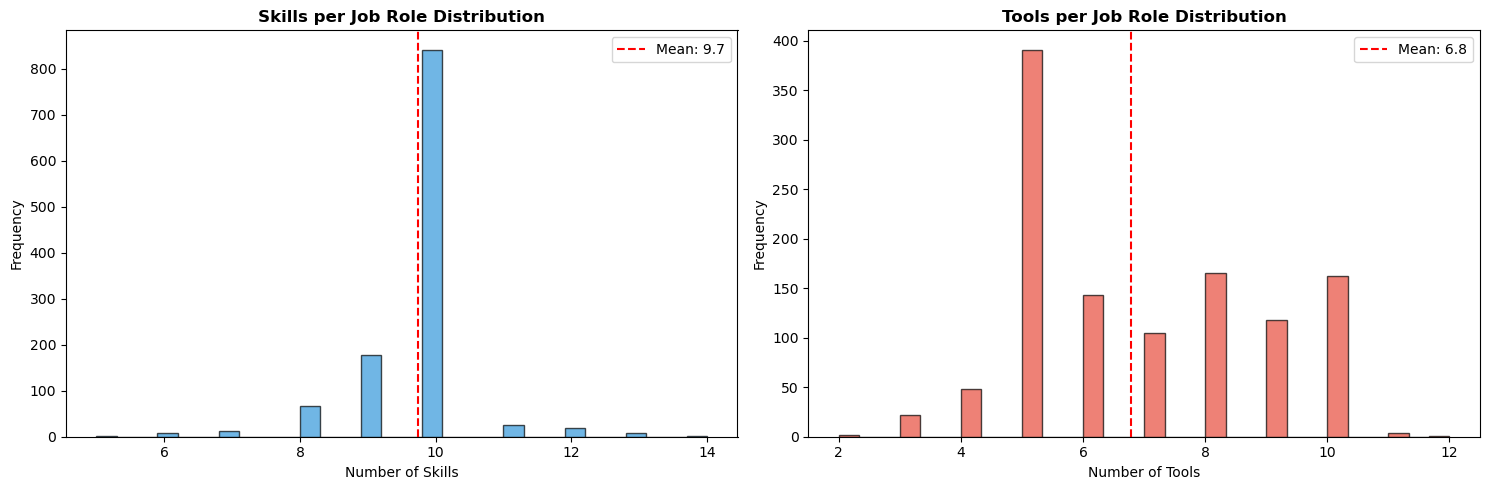

Analysis complete


In [17]:
# Comprehensive Skills & Tools Analysis for NLP Pipeline Planning

print("ANALYZING SKILLS & TOOLS COMPLEXITY FOR NLP PIPELINE")
print("=" * 60)

# Calculate actual item counts (better than comma counting)
def count_items(series):
    """Count actual items in comma-separated lists"""
    return series.apply(
        lambda x: len([item.strip() for item in str(x).split(',') if item.strip()]) 
        if pd.notna(x) and str(x).strip() else 0
    )

skills_count = count_items(df['Skills'])
tools_count = count_items(df['Tools'])

print("SKILLS ANALYSIS:")
print(f"   - Average skills per role: {skills_count.mean():.1f}")
print(f"   - Range: {skills_count.min()} to {skills_count.max()} skills")
print(f"   - Total unique skills needed: ~{skills_count.sum():,}")

print("\nTOOLS ANALYSIS:")
print(f"   - Average tools per role: {tools_count.mean():.1f}") 
print(f"   - Range: {tools_count.min()} to {tools_count.max()} tools")
print(f"   - Total unique tools needed: ~{tools_count.sum():,}")

print("\nNLP PIPELINE IMPLICATIONS:")
total_features_estimate = skills_count.max() + tools_count.max()
density = (skills_count.mean() + tools_count.mean()) / total_features_estimate
print(f"   - Estimated feature space: ~{total_features_estimate} dimensions")
print(f"   - Feature matrix density: {density:.1%} (very sparse)")
print(f"   - MultiLabelBinarizer appropriate for this sparse data")
print(f"   - Consider PCA/TF-IDF for dimensionality reduction")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(skills_count, bins=30, alpha=0.7, color='#3498db', edgecolor='black')
ax1.axvline(skills_count.mean(), color='red', linestyle='--', label=f'Mean: {skills_count.mean():.1f}')
ax1.set_title('Skills per Job Role Distribution', fontweight='bold', fontsize=12)
ax1.set_xlabel('Number of Skills')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(tools_count, bins=30, alpha=0.7, color='#e74c3c', edgecolor='black') 
ax2.axvline(tools_count.mean(), color='red', linestyle='--', label=f'Mean: {tools_count.mean():.1f}')
ax2.set_title('Tools per Job Role Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Number of Tools')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

print("Analysis complete")

In [18]:
# Comprehensive Delimiter Analysis for Tokenization Strategy

print("DELIMITER ANALYSIS - CRITICAL FOR NLP TOKENIZATION")
print("=" * 60)

# Analyze all potential delimiters across key columns
text_columns = ['Skills', 'Tools', 'Programming Languages', 'Job roles', 'Certifications']
delimiters = [',', ';', '|', '/', '\n', ' and ', ' & ']

print("DELIMITER FREQUENCY ANALYSIS:")
delimiter_summary = {}

for col in text_columns:
    print(f"\n{col}:")
    col_delim_counts = {}
    
    for delimiter in delimiters:
        # Handle newline character display
        display_delim = '\\n' if delimiter == '\n' else delimiter
        count = df[col].apply(lambda x: str(x).count(delimiter)).sum()
        col_delim_counts[delimiter] = count
        print(f"   '{display_delim}': {count:>6,} occurrences")
    
    # Find primary delimiter for this column
    if col_delim_counts:
        primary_delim = max(col_delim_counts, key=col_delim_counts.get)
        display_primary = '\\n' if primary_delim == '\n' else primary_delim
        print(f"   PRIMARY: '{display_primary}'")
    
    delimiter_summary[col] = col_delim_counts

print("\n" + "=" * 60)
print("TOKENIZATION STRATEGY DECISION:")

# Determine if we need multi-delimiter handling
needs_multi_delimiter = any(
    any(count > 0 for delim, count in counts.items() if delim not in [',', ';'])
    for col, counts in delimiter_summary.items()
)

if needs_multi_delimiter:
    print("   ❗ MULTIPLE DELIMITERS DETECTED")
    print("    Use multi-delimiter tokenization")
else:
    print("    CONSISTENT DELIMITERS")
    print("    Simple comma/semicolon splitting sufficient")

# Show real examples to validate strategy
print("\n VALIDATION - SAMPLE DATA:")
sample_data = df[['Skills', 'Tools']].dropna().head(3)
for idx, row in sample_data.iterrows():
    print(f"\nSample {idx}:")
    print(f"   Skills: {row['Skills']}")
    print(f"   Tools: {row['Tools']}")



DELIMITER ANALYSIS - CRITICAL FOR NLP TOKENIZATION
DELIMITER FREQUENCY ANALYSIS:

Skills:
   ',': 10,152 occurrences
   ';':      0 occurrences
   '|':      0 occurrences
   '/':    362 occurrences
   '\n':      0 occurrences
   ' and ':    251 occurrences
   ' & ':     56 occurrences
   PRIMARY: ','

Tools:
   ',':  6,707 occurrences
   ';':      0 occurrences
   '|':      1 occurrences
   '/':    134 occurrences
   '\n':      0 occurrences
   ' and ':      5 occurrences
   ' & ':      7 occurrences
   PRIMARY: ','

Programming Languages:
   ',':  4,149 occurrences
   ';':      0 occurrences
   '|':      0 occurrences
   '/':     10 occurrences
   '\n':      0 occurrences
   ' and ':      0 occurrences
   ' & ':      0 occurrences
   PRIMARY: ','

Job roles:
   ',':      6 occurrences
   ';':      0 occurrences
   '|':      0 occurrences
   '/':     51 occurrences
   '\n':      0 occurrences
   ' and ':      9 occurrences
   ' & ':     23 occurrences
   PRIMARY: '/'

Certifications:
 

# Convert the Certifications column into clean lists.
# Some cells are not strings (e.g., NaN or objects), so we first cast everything to string.
# Then we split only if a semicolon is present; otherwise return an empty list.
# Finally we strip whitespace and remove empty values.

In [19]:
df['Certifications'] = df['Certifications'].astype(str)


In [20]:
df['Certifications'] = df['Certifications'].replace(['None', 'nan', 'NaN'], '')

In [21]:
df['Certifications'] = (
    df['Certifications']
    .astype(str)
    .apply(lambda x: x.split(';') if ';' in x else [])
    .apply(lambda lst: [item.strip() for item in lst if item.strip() != ''])
)

In [22]:
df['Certifications'].head(10)

0    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
1    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
2    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
3    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
4    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
5    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
6    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
7    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
8    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
9    [AWS Machine Learning Specialty, Google ML Engineer, TensorFlow Developer]
Name: Certifications, dtype: object

In [23]:
text_cols = ['Skills', 'Tools', 'Programming Languages', 'Educational Background', 'Certifications']

for col in text_cols:
    df[col] = df[col].astype(str).str.replace('"', '').str.strip()


In [24]:
df.columns.tolist()

['Field',
 'Subfields',
 'Job roles',
 'Programming Languages',
 'Tools',
 'Skills',
 'Educational Background',
 'Certifications']

In [25]:
df['Certifications'].head(10).to_list()

["['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",
 "['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']"]

In [26]:
df['Skills'].head(10).to_list()

['Supervised learning, Unsupervised learning, Model evaluation, Data preprocessing, Feature engineering, Statistics, Communication, Problem-solving, Collaboration, Critical thinking',
 'Model deployment, Experimental design, Data wrangling, A/B testing, Causal inference, Feature selection, Communication, Critical thinking, Collaboration, Domain knowledge',
 'Theoretical modeling, Algorithm design, Literature review, Reproducibility, Statistical analysis, Optimization, Critical thinking, Research communication, Creativity, Collaboration',
 'Data cleaning, Statistical modeling, Regression analysis, Data visualization, Feature engineering, Business acumen, Problem-solving, Communication, Attention to detail, Time management',
 'Algorithm optimization, Model implementation, Low-latency systems, Data structures, Machine learning theory, Performance tuning, Debugging, Problem-solving, Collaboration, Critical thinking',
 'Model integration, Software design, Unit testing, Deployment pipelines,

# DATA PREPROCESSING & CLEANING

In [27]:
tech_vocabulary = {
    # ─────────────────────────────
    # Abbreviations → Full Terms
    # ─────────────────────────────
    'ml': 'machine learning',
    'ai': 'artificial intelligence',
    'dl': 'deep learning',
    'nlp': 'natural language processing',
    'cv': 'computer vision',
    'iot': 'internet of things',
    'rl': 'reinforcement learning',
    'llm': 'large language model',
    'sql': 'structured query language',
    'api': 'application programming interface',
    'ui': 'user interface',
    'ux': 'user experience',
    'saas': 'software as a service',
    'paas': 'platform as a service',
    'iaas': 'infrastructure as a service',
    'os': 'operating system',
    'vpn': 'virtual private network',
    'ide': 'integrated development environment',
    'ci/cd': 'continuous integration continuous deployment',
    'devops': 'development operations',

    # ─────────────────────────────
    # Programming Languages
    # ─────────────────────────────
    'js': 'javascript',
    'py': 'python',
    'c#': 'csharp',
    'c++': 'cpp',
    'ts': 'typescript',
    'rb': 'ruby',
    'go': 'golang',
    'rs': 'rust',
    'swift': 'swift',
    'kt': 'kotlin',
    'php': 'php',
    'html': 'hypertext markup language',
    'css': 'cascading style sheets',

    # ─────────────────────────────
    # Frameworks & Libraries
    # ─────────────────────────────
    'reactjs': 'react',
    'nodejs': 'node.js',
    'vue': 'vue.js',
    'angular': 'angular',
    'django': 'django',
    'flask': 'flask',
    'fastapi': 'fastapi',
    'spring': 'spring framework',

    # ML / Data / AI Frameworks
    'tensorflow': 'tensorflow',
    'pytorch': 'pytorch',
    'keras': 'keras',
    'scikit': 'scikit-learn',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'spark': 'apache spark',
    'hadoop': 'hadoop',

    # ─────────────────────────────
    # Cloud Platforms
    # ─────────────────────────────
    'aws': 'amazon web services',
    'gcp': 'google cloud platform',
    'azure': 'microsoft azure',
    'ec2': 'elastic compute cloud',
    's3': 'amazon simple storage service',
    'lambda': 'aws lambda',

    # ─────────────────────────────
    # Cybersecurity Terms
    # ─────────────────────────────
    'siem': 'security information and event management',
    'ids': 'intrusion detection system',
    'ips': 'intrusion prevention system',
    'soc': 'security operations center',
    'mfa': 'multi factor authentication',
    'ddos': 'distributed denial of service',
    'owasp': 'open web application security project',

    # ─────────────────────────────
    # Databases
    # ─────────────────────────────
    'mysql': 'mysql',
    'postgres': 'postgresql',
    'mongo': 'mongodb',
    'redis': 'redis',
    'db': 'database',
    'dbms': 'database management system',

    # ─────────────────────────────
    # Important Tech Certifications
    # ─────────────────────────────
    'aws ccp': 'aws certified cloud practitioner',
    'aws saa': 'aws solutions architect associate',
    'aws ml': 'aws machine learning specialty',
    'azure fundamentals': 'microsoft azure fundamentals',
    'gcp ace': 'google associate cloud engineer',

    'security+': 'comptia security plus',
    'network+': 'comptia network plus',
    'cysa+': 'comptia cybersecurity analyst',
    'ceh': 'certified ethical hacker',
    'ccna': 'cisco certified network associate',

    'ocp': 'oracle certified professional',
    'pmp': 'project management professional',
    'scrum master': 'certified scrum master',

    # AI / Data Certifications
    'google data analytics': 'google data analytics professional certificate',
    'google cybersecurity': 'google cybersecurity professional certificate',
    'google ai': 'google ai essentials certificate',
    'ibm data analyst': 'ibm data analyst professional certificate',
    'ibm ai engineering': 'ibm ai engineering professional certificate',
}


In [28]:
import re
import pandas as pd

# -------------------------------
# Text Cleaner
# -------------------------------
class DataPreprocessor:
    def __init__(self, tech_vocab_dict):
        self.tech_vocab_dict = tech_vocab_dict

    def clean_text(self, text):
        if text is None or str(text).lower() in ["none", "nan"]:
            return ""
        text = str(text).lower()
        text = re.sub(r"[^a-zA-Z0-9+ ]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        # Expand technical abbreviations
        for abbr, full in self.tech_vocab_dict.items():
            pattern = r"\b" + re.escape(abbr) + r"\b"
            text = re.sub(pattern, full, text)
        return text

# -------------------------------
# Data Handling
# -------------------------------
def handle_missing_values(df):
    return df.fillna("None")

def parse_multivalue_fields(df, preprocessor):
    text_columns = ['Skills', 'Tools', 'Programming Languages', 'Educational Background', 'Certifications']
    cleaned_map = {}

    for col in text_columns:
        if col in df.columns:
            clean_name = col.replace(" ", "_") + "_cleaned"
            df[clean_name] = df[col].apply(preprocessor.clean_text)
            cleaned_map[col] = clean_name

    # Convert to list safely
    for col, clean_name in cleaned_map.items():
        list_name = clean_name.replace("_cleaned", "_list")
        df[list_name] = df[clean_name].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()])

    # Combine text columns into a single field
    if cleaned_map:
        df['combined_text'] = df[[cleaned_map[c] for c in cleaned_map]].agg(" ".join, axis=1)
    else:
        df['combined_text'] = ""

    return df

def preprocess_data(df, preprocessor):
    print("🚀 Starting preprocessing...")
    
    # Fill missing values
    df = df.fillna("None")

    # Parse multivalue text fields
    df = parse_multivalue_fields(df, preprocessor)

    # Strip column names
    df.columns = df.columns.str.strip()

    print("✅ Preprocessing Completed!")
    return df


In [29]:
# Initialize your preprocessor with tech vocabulary
_preprocessor = DataPreprocessor(tech_vocabulary)

# Preprocess your DataFrame
df_processed = preprocess_data(df, _preprocessor)

# Check the first few rows
df_processed.head()


🚀 Starting preprocessing...
✅ Preprocessing Completed!


,Field,Subfields,Job roles,Programming Languages,Tools,Skills,Educational Background,Certifications,Skills_cleaned,Tools_cleaned,Programming_Languages_cleaned,Educational_Background_cleaned,Certifications_cleaned,Skills_list,Tools_list,Programming_Languages_list,Educational_Background_list,Certifications_list,combined_text
0,Artificial Intelligence,Machine Learning,Machine Learning Engineer,"Python, R, Java, Scala, C++","TensorFlow, PyTorch, Scikit-learn, Keras, Jupyter, Git, Docker, Spark","Supervised learning, Unsupervised learning, Model evaluation, Data preprocessing, Feature engineering, Statistics, Communication, Problem-solving, Collaboration, Critical thinking","Bachelor's (Computer Science, Data Science, Software Engineering)","['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",supervised learning unsupervised learning model evaluation data preprocessing feature engineering statistics communication problem solving collaboration critical thinking,tensorflow pytorch scikit-learn learn keras jupyter git docker apache spark,python r java scala c++,bachelor s computer science data science software engineering,amazon web services machine learning specialty google machine learning engineer tensorflow developer,[supervised learning unsupervised learning model evaluation data preprocessing feature engineering statistics communication problem solving collaboration critical thinking],[tensorflow pytorch scikit-learn learn keras jupyter git docker apache spark],[python r java scala c++],[bachelor s computer science data science software engineering],[amazon web services machine learning specialty google machine learning engineer tensorflow developer],supervised learning unsupervised learning model evaluation data preprocessing feature engineering statistics communication problem solving collaboration critical thinking tensorflow pytorch scikit-learn learn keras jupyter git docker apache spark python r java scala c++ bachelor s computer science data science software engineering amazon web services machine learning specialty google machine learning engineer tensorflow developer
1,Artificial Intelligence,Machine Learning,Applied Machine Learning Scientist,"Python, R, Julia, Scala, C++","TensorFlow, PyTorch, Scikit-learn, Jupyter, Git, MLflow, AWS, NumPy","Model deployment, Experimental design, Data wrangling, A/B testing, Causal inference, Feature selection, Communication, Critical thinking, Collaboration, Domain knowledge","Master's (Computer Science, AI, Data Science, Applied Mathematics)","['AWS Machine Learning Specialty', 'Google ML Engineer', 'TensorFlow Developer']",model deployment experimental design data wrangling a b testing causal inference feature selection communication critical thinking collaboration domain knowledge,tensorflow pytorch scikit-learn learn jupyter git mlflow amazon web services numpy,python r julia scala c++,master s computer science artificial intelligence data science applied mathematics,amazon web services machine learning specialty google machine learning engineer tensorflow developer,[model deployment experimental design data wrangling a b testing causal inference feature selection communication critical thinking collaboration domain knowledge],[tensorflow pytorch scikit-learn learn jupyter git mlflow amazon web services numpy],[python r julia scala c++],[master s computer science artificial intelligence data science applied mathematics],[amazon web services machine learning specialty google machine learning engineer tensorflow developer],model deployment experimental design data wrangling a b testing causal inference feature selection communication critical thinking collaboration domain knowledge tensorflow pytorch scikit-learn learn jupyter git mlflow amazon web services numpy python r julia scala c++ master s computer science artificial intelligence data science applied mathematics amazon web services machine learning specialty google machine learning engineer tens

# FEATURE ENGINEERING WITH SENTENCE-BERT

In [30]:
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except Exception:
    SENTENCE_TRANSFORMERS_AVAILABLE = False

use_sentence_bert = SENTENCE_TRANSFORMERS_AVAILABLE
sentence_model = None
if use_sentence_bert:
    try:
        sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
        print("✅ Sentence-BERT loaded")
    except Exception as e:
        print("⚠️ Sentence-BERT load failed:", e)
        sentence_model = None
        use_sentence_bert = False


✅ Sentence-BERT loaded


In [31]:
tfidf = None
mlb_skills = None
mlb_pl = None
mlb_tools = None
mlb_cert = None
label_encoder = None

def create_tfidf_features(texts, max_features=5000):
    global tfidf
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1,2), stop_words='english', min_df=2, max_df=0.95)
    X_tfidf = tfidf.fit_transform(texts)
    print("TF-IDF shape:", X_tfidf.shape)
    return X_tfidf

def create_mlb_features(df):
    global mlb_skills, mlb_pl, mlb_tools, mlb_cert

    mlb_skills = MultiLabelBinarizer()
    mlb_pl = MultiLabelBinarizer()
    mlb_tools = MultiLabelBinarizer()
    mlb_cert = MultiLabelBinarizer()

    skills_f = mlb_skills.fit_transform(df['Skills_list']) if 'Skills_list' in df.columns else csr_matrix((len(df), 0))
    pl_f     = mlb_pl.fit_transform(df['Programming_Languages_list']) if 'Programming_Languages_list' in df.columns else csr_matrix((len(df), 0))
    tools_f  = mlb_tools.fit_transform(df['Tools_list']) if 'Tools_list' in df.columns else csr_matrix((len(df), 0))
    cert_f   = mlb_cert.fit_transform(df['Certifications_list']) if 'Certifications_list' in df.columns else csr_matrix((len(df), 0))

    return skills_f, pl_f, tools_f, cert_f

def create_semantic_features(texts):
    if not use_sentence_bert or sentence_model is None:
        return csr_matrix((len(texts), 384))
    embeddings = sentence_model.encode(list(texts), show_progress_bar=True)
    return csr_matrix(embeddings)

def encode_target(y):
    global label_encoder
    label_encoder = LabelEncoder()
    y_enc = label_encoder.fit_transform(y)
    print("Encoded classes:", list(label_encoder.classes_))
    return y_enc

def create_hybrid_features(df):
    X_tfidf = create_tfidf_features(df['combined_text'])
    skills_f, pl_f, tools_f, cert_f = create_mlb_features(df)
    sem_f = create_semantic_features(df['combined_text'])
    X = hstack([X_tfidf, skills_f, pl_f, tools_f, cert_f, sem_f])
    print("Combined feature shape:", X.shape)
    return X

def save_preprocessing_objects(save_path="preprocessing_objects"):
    os.makedirs(save_path, exist_ok=True)
    objects = {
        'tfidf': tfidf,
        'mlb_skills': mlb_skills,
        'mlb_pl': mlb_pl,
        'mlb_tools': mlb_tools,
        'mlb_cert': mlb_cert,
        'label_encoder': label_encoder,
        'sentence_model': sentence_model if use_sentence_bert else None
    }
    for name, obj in objects.items():
        if obj is not None:
            with open(os.path.join(save_path, f"{name}.pkl"), "wb") as f:
                pickle.dump(obj, f)
            print("Saved:", name + ".pkl")

# ------------------------------
# Run preprocessing & feature creation
# ------------------------------

# preprocessor instance
_preprocessor = DataPreprocessor(tech_vocabulary)

df_processed = preprocess_data(df, preprocessor=_preprocessor)
X = create_hybrid_features(df_processed)
y = encode_target(df_processed['Field'])
save_preprocessing_objects("preprocessing_objects")


🚀 Starting preprocessing...
✅ Preprocessing Completed!
TF-IDF shape: (1161, 5000)


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Combined feature shape: (1161, 8672)
Encoded classes: ['AR/VR & Spatial Computing', 'Artificial Intelligence', 'Bioinformatics & HealthTech', 'Blockchain & Web3', 'CRM / ERP Systems', 'ClimateTech & SpaceTech', 'Cloud Computing', 'Cybersecurity', 'Data Science', 'Database & Storage', 'DevOps & SRE', 'Digital & Marketing Technology', 'E-Commerce Technology', 'EdTech', 'Embedded Systems', 'Emerging & Cross-Cutting', 'FinTech & InsurTech', 'Game Development', 'IT Support & System Administration', 'Internet of Things (IoT)', 'LegalTech & GovTech', 'Mobile Development', 'Networking & Telecom', 'Performance & Reliability Engineering', 'Quantum Computing', 'Robotics', 'UI/UX & Product Design', 'Web Development']
Saved: tfidf.pkl
Saved: mlb_skills.pkl
Saved: mlb_pl.pkl
Saved: mlb_tools.pkl
Saved: mlb_cert.pkl
Saved: label_encoder.pkl
Saved: sentence_model.pkl


# Handling & Visualizing Class Imbalance (with Oversampling)

In [32]:
#  Visualize class distribution

def visualize_class_distribution(y, label_encoder, title="Class Distribution"):
    class_counts = Counter(y)
    labels = [label_encoder.inverse_transform([c])[0] for c in class_counts.keys()]
    counts = list(class_counts.values())
    plt.figure(figsize=(8,4))
    sns.barplot(x=labels, y=counts)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

X_balanced, y_balanced = None, None
def oversample_data(X, y):
    ros = RandomOverSampler(random_state=42)
    Xr, yr = ros.fit_resample(X, y)
    return Xr, yr

X_balanced, y_balanced = oversample_data(X, y)
print("Balanced sizes:", X_balanced.shape, y_balanced.shape)


Balanced sizes: (2940, 8672) (2940,)


# MODEL TRAINING & EVALUATION

In [33]:
trained_models = {}
cv_results = {}

def train_all_models(X, y, test_size=0.2, random_state=42):
    global trained_models, cv_results

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Updated models dictionary (LightGBM added)
    models = {
        "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1),
        "xgboost": XGBClassifier(n_estimators=200, random_state=random_state, n_jobs=-1, eval_metric="mlogloss"),
        "svm": SVC(probability=True, random_state=random_state),
        "lightgbm": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=random_state,
            n_jobs=-1
        )
    }

    results = {}

    # Train models
    for name, m in models.items():
        print("Training", name)
        m.fit(X_train, y_train)
        trained_models[name] = m

        # Evaluate
        y_pred = m.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results[name] = {"accuracy": acc, "f1": f1}

        print(f"{name}: acc={acc:.4f}, f1={f1:.4f}")

    return results, X_train, X_test, y_train, y_test, models

def perform_cross_validation(X, y, models, cv=5):
    global cv_results
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
        cv_results[name] = {"mean_accuracy": scores.mean(), "std_accuracy": scores.std(), "all_scores": scores}
        print(f"{name} CV mean acc: {scores.mean():.4f}")

def create_ensemble_model(X, y):
    estimators = [(name, m) for name, m in trained_models.items()]
    ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
    ensemble.fit(X, y)
    trained_models['ensemble'] = ensemble
    return ensemble

def save_all_models(path="models"):
    os.makedirs(path, exist_ok=True)
    for name, model in trained_models.items():
        with open(os.path.join(path, f"{name}.pkl"), "wb") as f:
            pickle.dump(model, f)
    with open(os.path.join(path, "training_results.pkl"), "wb") as f:
        pickle.dump({"cv_results": cv_results}, f)
    print("Models and training results saved in", path)

# Train and save
results, X_train, X_test, y_train, y_test, models = train_all_models(X_balanced, y_balanced)
perform_cross_validation(X_balanced, y_balanced, models)
best_name = max(cv_results.items(), key=lambda x: x[1]['mean_accuracy'])[0]
print("Best by CV:", best_name)
ensemble = create_ensemble_model(X_balanced, y_balanced)
save_all_models("models")

Training decision_tree
decision_tree: acc=0.9762, f1=0.9763
Training random_forest
random_forest: acc=0.9898, f1=0.9897
Training xgboost
xgboost: acc=0.9915, f1=0.9915
Training svm
svm: acc=0.9932, f1=0.9932
Training lightgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133040
[LightGBM] [Info] Number of data points in the train set: 2352, number of used features: 2152
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332

#  MODEL EVALUATION

In [34]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)


In [35]:
def evaluate_model(model, X_test, y_test, model_name, classes):
    y_pred = model.predict(X_test)
    try:
        print(classification_report(y_test, y_pred, target_names=classes))
    except:
        print(classification_report(y_test, y_pred))
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    }

classes = [str(c) for c in label_encoder.classes_]
results_all = {}
for name, model in trained_models.items():
    if name != 'ensemble':
        results_all[name] = evaluate_model(model, X_test, y_test, name, classes)
comparison_df = pd.DataFrame(results_all).T.sort_values('f1', ascending=False)
print(comparison_df)

                                       precision    recall  f1-score   support

            AR/VR & Spatial Computing       1.00      1.00      1.00        21
              Artificial Intelligence       1.00      0.86      0.92        21
          Bioinformatics & HealthTech       0.80      0.95      0.87        21
                    Blockchain & Web3       1.00      1.00      1.00        21
                    CRM / ERP Systems       1.00      0.95      0.98        21
              ClimateTech & SpaceTech       1.00      0.95      0.98        21
                      Cloud Computing       1.00      0.95      0.98        21
                        Cybersecurity       0.95      0.95      0.95        21
                         Data Science       1.00      0.95      0.98        21
                   Database & Storage       0.95      1.00      0.98        21
                         DevOps & SRE       1.00      0.95      0.98        21
       Digital & Marketing Technology       1.00   

# PREDICTION PIPELINE

In [42]:
import os
import pickle
import re
import numpy as np
from scipy.sparse import csr_matrix, hstack

# -------------------------------
# Preprocessor
# -------------------------------
class DataPreprocessor:
    def __init__(self, tech_vocab_dict):
        self.tech_vocab_dict = tech_vocab_dict

    def clean_text(self, text):
        if text is None or str(text).lower() in ["none", "nan"]:
            return ""
        text = str(text).lower()
        text = re.sub(r"[^a-zA-Z0-9+ ]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        # Expand technical abbreviations
        for abbr, full in self.tech_vocab_dict.items():
            pattern = r"\b" + re.escape(abbr) + r"\b"
            text = re.sub(pattern, full, text)

        return text


# -------------------------------
# Career Recommender
# -------------------------------
class CareerRecommender:
    def __init__(self, models_path="models", preprocessing_objects_path="preprocessing_objects",
                 use_ensemble=True, tech_vocabulary=None):

        self.models_path = models_path
        self.preprocessing_objects_path = preprocessing_objects_path
        self.use_ensemble = use_ensemble

        # Load objects
        def load_obj(p):
            try:
                with open(p, "rb") as f:
                    return pickle.load(f)
            except Exception:
                return None

        self.tfidf = load_obj(os.path.join(preprocessing_objects_path, "tfidf.pkl"))
        self.mlb_skills = load_obj(os.path.join(preprocessing_objects_path, "mlb_skills.pkl"))
        self.mlb_pl = load_obj(os.path.join(preprocessing_objects_path, "mlb_pl.pkl"))
        self.mlb_tools = load_obj(os.path.join(preprocessing_objects_path, "mlb_tools.pkl"))
        self.mlb_cert = load_obj(os.path.join(preprocessing_objects_path, "mlb_cert.pkl"))
        self.label_encoder = load_obj(os.path.join(preprocessing_objects_path, "label_encoder.pkl"))
        self.sentence_model = load_obj(os.path.join(preprocessing_objects_path, "sentence_model.pkl"))

        # Preprocessor
        self.preprocessor = DataPreprocessor(tech_vocabulary or {})

        # Load models
        self.trained_models = {}
        for fname in os.listdir(models_path):
            if fname.endswith(".pkl"):
                key = fname.replace(".pkl", "")
                try:
                    with open(os.path.join(models_path, fname), "rb") as f:
                        self.trained_models[key] = pickle.load(f)
                except Exception as e:
                    print("Failed to load", fname, e)

        # Select model
        if use_ensemble and "ensemble" in self.trained_models:
            self.model = self.trained_models["ensemble"]
        else:
            try:
                with open(os.path.join(models_path, "training_results.pkl"), "rb") as f:
                    tr = pickle.load(f)
                accuracies = {k: v['mean_accuracy'] for k, v in tr.get("cv_results", {}).items()}
                best = max(accuracies, key=accuracies.get)
                self.model = self.trained_models.get(best, list(self.trained_models.values())[0])
            except Exception:
                self.model = list(self.trained_models.values())[0] if self.trained_models else None

        print("CareerRecommender ready. Model loaded:", getattr(self.model, "__class__", None))


    # ---------------------------------------------
    # Normalization for flexible matching
    # ---------------------------------------------
    def normalize(self, s):
        s = s.lower()
        s = re.sub(r'[^a-z0-9+ ]', ' ', s)
        s = re.sub(r'\s+', ' ', s).strip()
        return s

    # ---------------------------------------------
    # Flexible vocab matcher
    # ---------------------------------------------
    def match_vocab(self, vocab_list, text):
        text_norm = self.normalize(text)
        matches = []

        for v in vocab_list:
            v_norm = self.normalize(v)
            v_words = v_norm.split()

            # Full phrase match
            if v_norm in text_norm:
                matches.append(v)
                continue

            # All words appear
            if all(word in text_norm for word in v_words):
                matches.append(v)
                continue

            # Partial match for longer words
            if any(word in text_norm for word in v_words if len(word) > 2):
                matches.append(v)

        return list(dict.fromkeys(matches))  # remove duplicates, keep order


    # -------------------------------
    # Feature Extraction
    # -------------------------------
    def extract_features_from_text(self, text):
        cleaned_text = self.preprocessor.clean_text(text)

        # TF-IDF
        tfidf_features = self.tfidf.transform([cleaned_text]) if self.tfidf else csr_matrix((1,0))

        # Vocabulary matching
        skills_list = self.match_vocab(self.mlb_skills.classes_, cleaned_text) if self.mlb_skills else []
        pl_list     = self.match_vocab(self.mlb_pl.classes_, cleaned_text) if self.mlb_pl else []
        tools_list  = self.match_vocab(self.mlb_tools.classes_, cleaned_text) if self.mlb_tools else []
        cert_list   = self.match_vocab(self.mlb_cert.classes_, cleaned_text) if self.mlb_cert else []

        # Encode lists
        skills_encoded = self.mlb_skills.transform([skills_list]) if self.mlb_skills else csr_matrix((1,0))
        pl_encoded     = self.mlb_pl.transform([pl_list])         if self.mlb_pl else csr_matrix((1,0))
        tools_encoded  = self.mlb_tools.transform([tools_list])   if self.mlb_tools else csr_matrix((1,0))
        cert_encoded   = self.mlb_cert.transform([cert_list])     if self.mlb_cert else csr_matrix((1,0))

        # Semantic
        semantic_features = csr_matrix((1,384))
        if self.sentence_model:
            try:
                emb = self.sentence_model.encode([text])
                semantic_features = csr_matrix(emb)
            except Exception as e:
                print("Semantic feature error:", e)

        combined = hstack([
            tfidf_features,
            skills_encoded,
            pl_encoded,
            tools_encoded,
            cert_encoded,
            semantic_features
        ])

        return combined, {
            "skills_found": skills_list,
            "programming_languages": pl_list,
            "tools": tools_list,
            "certifications": cert_list,
            "semantic_used": self.sentence_model is not None
        }


    # -------------------------------
    # Prediction
    # -------------------------------
    def predict_career(self, text, top_k=3):
        features, meta = self.extract_features_from_text(text)

        pred = self.model.predict(features)[0]
        probs = self.model.predict_proba(features)[0]

        top_idx = np.argsort(probs)[-top_k:][::-1]
        top_preds = [{
            "field": self.label_encoder.inverse_transform([int(i)])[0],
            "confidence": float(probs[i])
        } for i in top_idx]

        main = {
            "field": self.label_encoder.inverse_transform([int(pred)])[0],
            "confidence": float(np.max(probs))
        }

        return {"success": True, "main_prediction": main, "top_predictions": top_preds, "metadata": meta}


In [43]:
recommender = CareerRecommender(models_path="models", preprocessing_objects_path="preprocessing_objects", use_ensemble=True)

sample_text = "Experienced in Python, SQL, machine learning, pandas, scikit-learn, tensorflow. AWS certified."
print(recommender.predict_career(sample_text, top_k=3))

CareerRecommender ready. Model loaded: <class 'sklearn.ensemble._voting.VotingClassifier'>
{'success': True, 'main_prediction': {'field': 'Artificial Intelligence', 'confidence': 0.27112119564099524}, 'top_predictions': [{'field': 'Artificial Intelligence', 'confidence': 0.27112119564099524}, {'field': 'Mobile Development', 'confidence': 0.23055783661403004}, {'field': 'Bioinformatics & HealthTech', 'confidence': 0.03267363511394666}], 'metadata': {'skills_found': ['3d asset creation texturing animation storytelling user interface user experience pipeline integration prototyping creative problem solving collaboration', '3d math spatial mapping shader programming interaction design performance optimization debugging user experience cross platform deployment', '3d spatial mapping computer vision sensor fusion slam ar vr development spatial reasoning real time systems problem solving teamwork user experience design', '3d user interface user experience design interaction design spatial rea

In [44]:
import PyPDF2

def extract_text_from_pdf(pdf_path):
    """Extract raw text from a PDF resume file"""
    try:
        text = ""
        with open(pdf_path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += page.extract_text() + "\n"
        return text
    
    except Exception as e:
        print(f"❌ Error reading PDF: {e}")
        return ""
    
pdf_path = "C:\\Masar\\masar____final\\Nada Aldossary - Resume .pdf" 
resume_text = extract_text_from_pdf(pdf_path)   
print(recommender.predict_career(resume_text, top_k=3))

{'success': True, 'main_prediction': {'field': 'IT Support & System Administration', 'confidence': 0.5726340132650561}, 'top_predictions': [{'field': 'IT Support & System Administration', 'confidence': 0.5726340132650561}, {'field': 'Mobile Development', 'confidence': 0.0693603928754291}, {'field': 'Cybersecurity', 'confidence': 0.040792361195569365}], 'metadata': {'skills_found': ['24 7 network monitoring incident response alarm analysis fault diagnosis escalation procedures outage documentation basic troubleshooting remote troubleshooting service restoration real time network analytics', '2d 3d graphics animation shader programming physics asset integration performance optimization user interface profiling debugging collaboration', '3d asset creation animation interactive storytelling pipeline integration prototyping optimization troubleshooting creativity teamwork', '3d asset creation texturing animation storytelling user interface user experience pipeline integration prototyping cr